<a href="https://colab.research.google.com/github/sanjuchatrathi-star/ML/blob/main/Experiment_3_Postlab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load Titanic Dataset from GitHub
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Remove unnecessary columns
df.drop(["PassengerId","Name","Ticket","Cabin"], axis=1, inplace=True)

# Fill missing values
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Encode categorical columns
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])
df["Embarked"] = le.fit_transform(df["Embarked"])

# Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

/tmp/ipykernel_1074/1951949690.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_1074/1951949690.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy")
print(accuracy_score(y_test, lr_pred))

# Linear Discriminant Analysis
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
lda_pred = lda.predict(X_test)

print("LDA Accuracy")
print(accuracy_score(y_test, lda_pred))

# K-Nearest Neighbors
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("KNN Accuracy")
print(accuracy_score(y_test, knn_pred))

Logistic Regression Accuracy
0.8100558659217877
LDA Accuracy
0.7932960893854749
KNN Accuracy
0.7039106145251397


In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Naive Bayes Accuracy")
print(accuracy_score(y_test, nb_pred))

# Support Vector Machine
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

print("SVM Accuracy")
print(accuracy_score(y_test, svm_pred))

Naive Bayes Accuracy
0.776536312849162


In [18]:
from sklearn.metrics import precision_score

print("Precision")
print(precision_score(y_test, lr_pred))

Precision
0.7857142857142857


In [27]:
from sklearn.metrics import confusion_matrix

print("Confusion Matrix 24EU01073")
print(confusion_matrix(y_test, lr_pred))

Confusion Matrix 24EU01073
[[90 15]
 [19 55]]


In [19]:
from sklearn.metrics import recall_score

print("Recall")
print(recall_score(y_test, lr_pred))

Recall
0.7432432432432432


In [20]:
from sklearn.metrics import f1_score

print("F1 Score")
print(f1_score(y_test, lr_pred))

F1 Score
0.7638888888888888


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



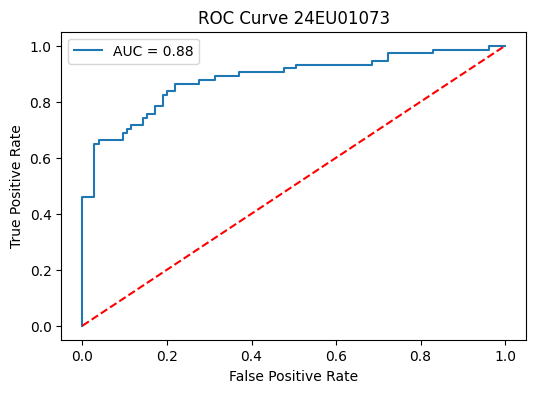

In [22]:
from sklearn.metrics import roc_curve, auc

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve 24EU01073")
plt.legend()
plt.show()

In [23]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(lr, X, y, cv=5)

print("Cross Validation Scores")
print(scores)

print("Average Accuracy")
print(scores.mean())

Cross Validation Scores
[0.7877095  0.78651685 0.78089888 0.76966292 0.82022472]
Average Accuracy
0.7890025735986442


In [24]:
print("Logistic Regression :", accuracy_score(y_test, lr_pred))
print("LDA                 :", accuracy_score(y_test, lda_pred))
print("KNN                 :", accuracy_score(y_test, knn_pred))
print("Naive Bayes         :", accuracy_score(y_test, nb_pred))
print("SVM                 :", accuracy_score(y_test, svm_pred))

Logistic Regression : 0.8100558659217877
LDA                 : 0.7932960893854749
KNN                 : 0.7039106145251397
Naive Bayes         : 0.776536312849162
SVM                 : 0.7821229050279329
